# **Plotting the Data Part 2**

In this section, we will explore additional plotting techniques to visualize our text data. Although its still `matplotlib` that we will be using, we will try different approaches to visualize the data.

## Pandas and Plotting

Rather than using `matplotlib` directly, we can also use the plotting capabilities of `pandas`, which provides a convenient interface for creating various types of plots directly from DataFrames. This can simplify the process of visualizing data and allows us to quickly generate plots without needing to import `matplotlib` separately.

Lets use the `tips` dataset to demonstrate how to use `pandas` for plotting.

In [1]:
import pandas as pd

tips_dataset = "./tips.csv"

tips = pd.read_csv(tips_dataset)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


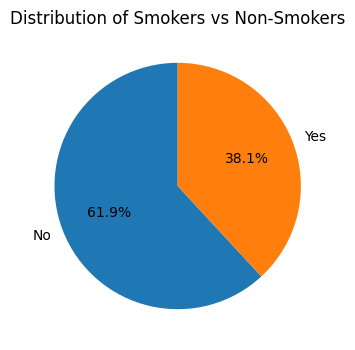

In [2]:
# plt still required for plotting, even when using pandas plotting capabilities
import matplotlib.pyplot as plt

# Creating a pie chart of the distribution of smokers vs non-smokers
smoker_counts = tips["smoker"].value_counts()
smoker_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, figsize=(4, 4))
plt.title("Distribution of Smokers vs Non-Smokers")
plt.ylabel("")  # Hide the y-label

plt.show()

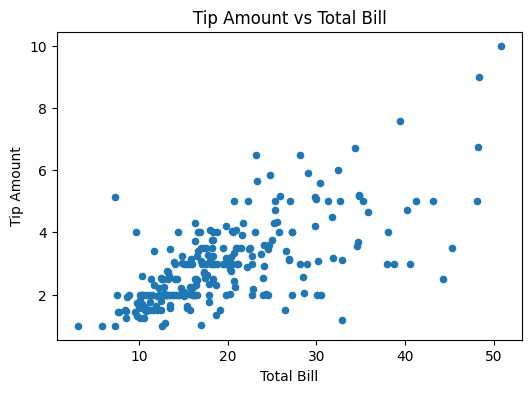

In [3]:
# Creating a distribution of total bill vs tip amount
tips.plot(kind="scatter", x="total_bill", y="tip", figsize=(6, 4), legend=True)
plt.title("Tip Amount vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip Amount")

plt.show()

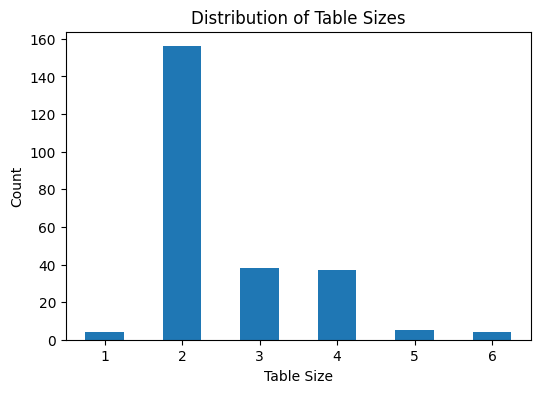

In [4]:
# Creating barchart of table size
table_size_counts = tips["size"].value_counts().sort_index()
table_size_counts.plot(kind="bar", figsize=(6, 4), rot=0)
plt.title("Distribution of Table Sizes")
plt.xlabel("Table Size")
plt.ylabel("Count")

plt.show()

## Data Normalization

Common problem in data analysis is that the data can be on different scales, which can make it difficult to compare and visualize. Data normalization is a technique used to scale the data to a common range, typically between 0 and 1, or to have a mean of 0 and a standard deviation of 1. This can help improve the performance of machine learning algorithms and make it easier to visualize the data.

A simple way to normalize data is to use *Min-Max Normalization*, which scales the data to a range of [0, 1]. The formula for Min-Max Normalization is:

```
X_normalized = (X - X_min) / (X_max - X_min)
```

To simplify the process of normalization, we can use the `MinMaxScaler` from the `sklearn.preprocessing` module, which provides a convenient way to perform Min-Max Normalization on our data.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the 'total_bill' and 'tip' columns using MinMaxScaler
scaler = MinMaxScaler()
tips[["total_bill_normalized", "tip_normalized"]] = scaler.fit_transform(
    tips[["total_bill", "tip"]]
)
tips.head()

,total_bill,tip,sex,smoker,day,time,size,total_bill_normalized,tip_normalized
0,16.99,1.01,Female,No,Sun,Dinner,2,0.291579,0.001111
1,10.34,1.66,Male,No,Sun,Dinner,3,0.152283,0.073333
2,21.01,3.50,Male,No,Sun,Dinner,3,0.375786,0.277778
3,23.68,3.31,Male,No,Sun,Dinner,2,0.431713,0.256667
4,24.59,3.61,Female,No,Sun,Dinner,4,0.450775,0.290000


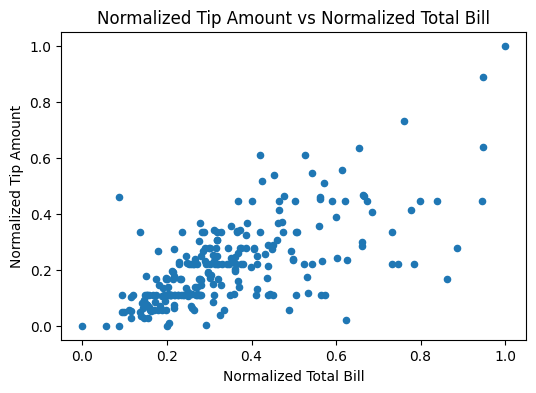

In [ ]:
# Plot the normalized data
tips.plot(
    kind="scatter",
    x="total_bill_normalized",
    y="tip_normalized",
    figsize=(6, 4),
    legend=True,
)
plt.title("Normalized Tip Amount vs Normalized Total Bill")
plt.xlabel("Normalized Total Bill")
plt.ylabel("Normalized Tip Amount")

plt.show()

We can see the scatter plot of the normalized data, it doesn't have any difference in the shape of the data, but the values are now scaled to a range of [0, 1], which can make it easier to compare and visualize the data.

In this case its not really helpful because the original data is already in a reasonable range, but in cases where the data has a wide range of values, normalization can help to prevent certain features from dominating the visualization and allows us to see patterns and relationships more clearly.

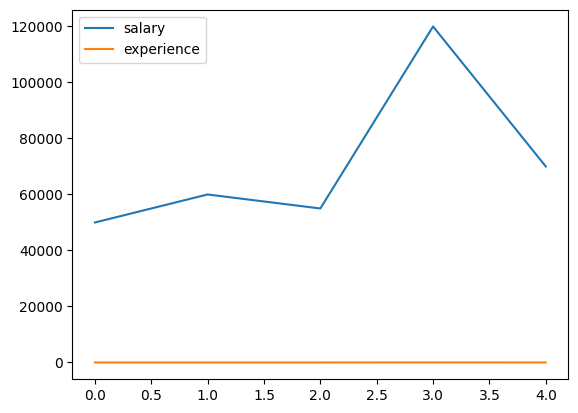

In [ ]:
# Example of data with huge range of values

salary_data = pd.DataFrame(
    {
        "salary": [50000, 60000, 55000, 120000, 70000],
        "experience": [1, 2, 1.5, 10, 3],
    }
)

salary_data.plot()

plt.show()

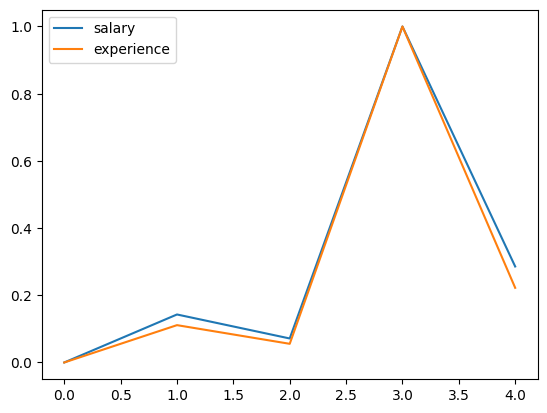

In [ ]:
# Normalize the salary data
scaler = MinMaxScaler()
normalized = salary_data.copy()
normalized[["salary", "experience"]] = scaler.fit_transform(
    salary_data[["salary", "experience"]]
)

# Plot the normalized salary data
normalized.plot()

plt.show()

By normalizing the data we can see the patterns and relationships more clearly, where the salary is having linear relationship with experience, and the values are now in a range of [0, 1], which can make it easier to compare and visualize the data.

## Time Series and Smoothing Trends

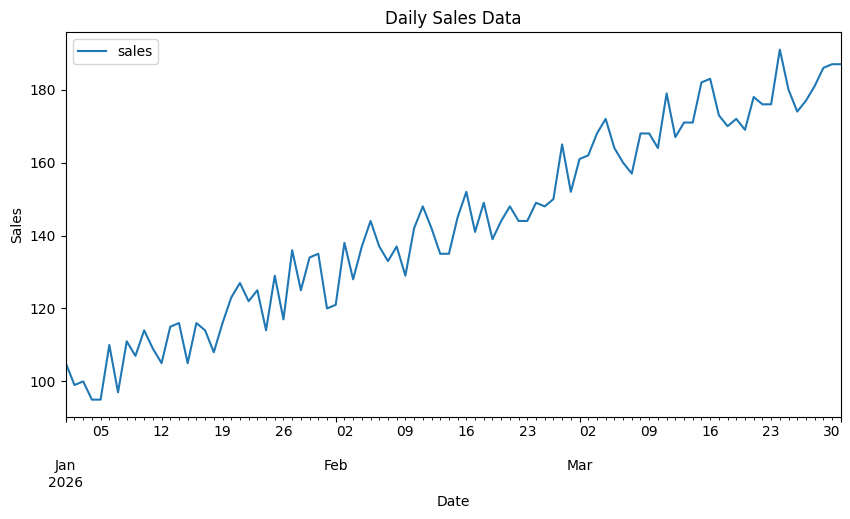

In [21]:
import random

# Create a time series dataset with daily sales data for 3 months
date_rng = pd.date_range(start="2026-01-01", end="2026-03-31", freq="D")
sales = pd.DataFrame(date_rng, columns=["date"])

# Generate random sales data that has a general upward trend with some noise
sales["sales"] = [100 + random.randint(-10, 10) + i for i in range(len(date_rng))]

sales.set_index("date", inplace=True)

# Plot the original sales data
sales.plot(figsize=(10, 5))
plt.title("Daily Sales Data")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

Time series data is often "noisy", the high daily fluctuations can hide the overall direction of the data. To handle this, we convert strings to Datetime Objects and use Rolling Windows (Moving Averages). This "smooths" the line, allowing us to see the signal through the noise. 

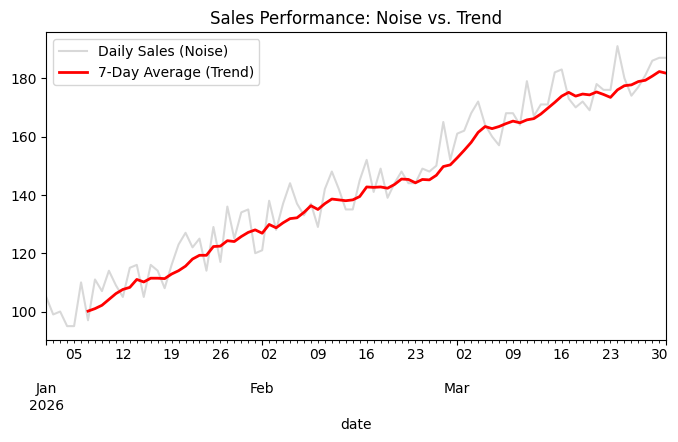

In [30]:
# Calculate the rolling mean with a window of 7 days
sales["7day_avg"] = sales["sales"].rolling(window=7).mean()

_, ax = plt.subplots(figsize=(8, 4))
sales.plot(y="sales", label="Daily Sales (Noise)", alpha=0.3, color="gray", ax=ax)
sales.plot(y="7day_avg", label="7-Day Average (Trend)", color="red", linewidth=2, ax=ax)

plt.title("Sales Performance: Noise vs. Trend")
plt.legend()
plt.show()

Instead of the mean, we can also use other functions like median, min, max, etc. to calculate the rolling values. This can be useful in cases where the data has outliers or is not normally distributed, as the mean can be affected by extreme values, while the median is more robust to outliers. By using different functions for rolling calculations, we can gain different insights into the data and better understand its underlying patterns and trends.

<Figure size 1200x600 with 0 Axes>

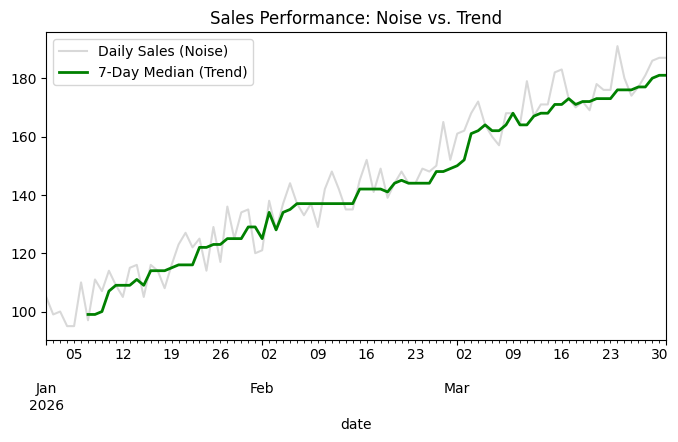

In [ ]:
# Calculate the rolling median with a window of 7 days
sales["7day_median"] = sales["sales"].rolling(window=7).median()

_, ax = plt.subplots(figsize=(8, 4))
sales.plot(y="sales", label="Daily Sales (Noise)", alpha=0.3, color="gray", ax=ax)
sales.plot(
    y="7day_median", label="7-Day Median (Trend)", color="green", linewidth=2, ax=ax
)

plt.title("Sales Performance: Noise vs. Trend")
plt.legend()

plt.show()

## Subplots

In the context of `matplotlib`, subplots refer to the ability to create multiple plots within a single figure. This allows us to visualize multiple aspects of our data side by side, making it easier to compare and analyze different variables or relationships. Subplots can be arranged in a grid format, where each subplot occupies a specific position within the grid. This is particularly useful when we want to display multiple related plots together, such as different features of a dataset or different time series. By using subplots, we can effectively communicate complex information and insights from our data in a clear and organized manner.

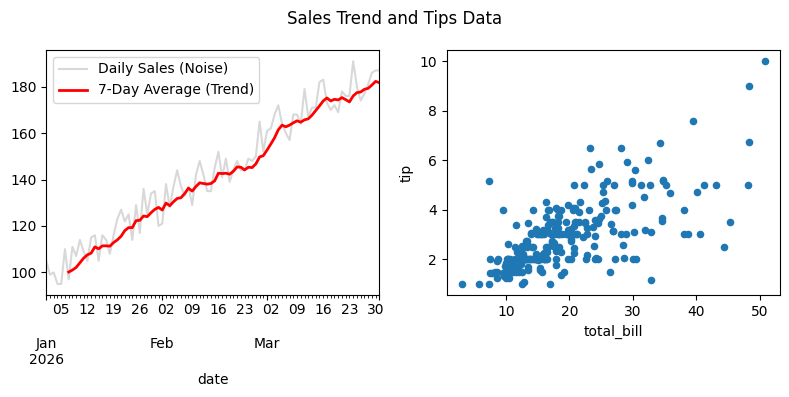

In [48]:
# Example of joining the two datasets and plotting them together
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

# nrows=1, ncols=2 creates a grid of 1 row and 2 columns for subplots
# axes will be a list of axes objects corresponding to each subplot
# axes[0] is the first subplot, axes[1] is the second subplot, and so on.

# Plot the sales data on the first subplot
sales.plot(y="sales", label="Daily Sales (Noise)", alpha=0.3, color="gray", ax=axes[0])
sales.plot(
    y="7day_avg", label="7-Day Average (Trend)", color="red", linewidth=2, ax=axes[0]
)

# Plot the tips data on the second subplot
tips.plot(kind="scatter", x="total_bill", y="tip", legend=True, ax=axes[1])

fig.suptitle("Sales Trend and Tips Data")
fig.tight_layout()  # Adjust layout to prevent overlap

plt.show()